In [196]:
import imageio
import netCDF4 as nc
import numpy as np
import os
import pygmt
import re
import rioxarray as rio
from scipy.ndimage import gaussian_filter
import shutil
import subprocess
import sys
import xarray as xr
import xesmf as xe

In [197]:
age = 90

## Clip to shelves


Ensemble grids

In [198]:
ensemble = f'photozoan/proj_{age}Ma/proj_{age}Ma_photozoan_ensemble.tif'
ensembleDS = xr.open_dataset(ensemble)
ensembleDS

<xarray.Dataset> Size: 58kB
Dimensions:      (band: 7, x: 64, y: 32)
Coordinates:
  * band         (band) int64 56B 1 2 3 4 5 6 7
  * x            (x) float64 512B 2.812 8.438 14.06 19.69 ... 345.9 351.6 357.2
  * y            (y) float64 256B 85.76 80.23 74.69 ... -74.69 -80.23 -85.76
    spatial_ref  int64 8B ...
Data variables:
    band_data    (band, y, x) float32 57kB ...

In [199]:
# Convert to lons and lats
dataType = ['e_mean','cv','e_median','ca','wmean','ciInf', 'ciSup']

dataName = ['Mean', 'Coefficient of variation', 'Median', 
            'Committee averaging score', 'Weighted mean', 
            'Confidence interval (lower)', 'Confidence interval (upper)']

k = -1
for k in range(len(dataType)):
    nda = xr.DataArray(
                    ensembleDS.isel(band=k).band_data.values,
                    dims=["latitude", "longitude"],
                    coords={"latitude": ensembleDS.y.values, "longitude": ensembleDS.x.values},
                )

    if k == 0:
        dataEM = nda.to_dataset(name=dataType[k])

    tmp = nda.fillna(0).values
    dataEM[dataType[k]] = (('latitude', 'longitude'), gaussian_filter(tmp,1))

dataEM

<xarray.Dataset> Size: 58kB
Dimensions:    (latitude: 32, longitude: 64)
Coordinates:
  * latitude   (latitude) float64 256B 85.76 80.23 74.69 ... -80.23 -85.76
  * longitude  (longitude) float64 512B 2.812 8.438 14.06 ... 345.9 351.6 357.2
Data variables:
    e_mean     (latitude, longitude) float32 8kB 17.67 21.26 ... 0.07681 0.0168
    cv         (latitude, longitude) float32 8kB 363.3 318.3 ... 0.05654 0.02056
    e_median   (latitude, longitude) float32 8kB 0.0 0.0 ... 0.03648 0.008402
    ca         (latitude, longitude) float32 8kB 0.0 0.0 0.0 ... 0.1076 0.03492
    wmean      (latitude, longitude) float32 8kB 17.71 21.63 ... 0.07671 0.01663
    ciInf      (latitude, longitude) float32 8kB 0.0 0.0 ... 0.004521 0.0008313
    ciSup      (latitude, longitude) float32 8kB 63.27 68.89 ... 0.1501 0.03304

In [202]:
# Shift half a grid length (if needed)
# grid = dataEM
outgrid = 'dataEM_realigned.nc'
if os.path.exists(outgrid):
    os.remove(outgrid)
data = dataEM

leftExtent = float(data.longitude[0])

if leftExtent < 0.1:
    shift = (float(data.longitude[1]) - float(data.longitude[0]))/2

    data['longitude'] = data.longitude + np.abs(shift)

    # Remove the FillValue that xarray automaticcaly puts in (stuffs up some of the plotting)
    enc = dict(_FillValue=None)
    encoding = {var:enc for var in data.data_vars}

    data.to_netcdf(path=outgrid, encoding=encoding)


In [204]:
# ensembleRealigned = xr.open_dataset(outgrid)
ensembleRealigned = dataEM
ensembleRealigned


<xarray.Dataset> Size: 58kB
Dimensions:    (latitude: 32, longitude: 64)
Coordinates:
  * latitude   (latitude) float64 256B 85.76 80.23 74.69 ... -80.23 -85.76
  * longitude  (longitude) float64 512B 2.812 8.438 14.06 ... 345.9 351.6 357.2
Data variables:
    e_mean     (latitude, longitude) float32 8kB 17.67 21.26 ... 0.07681 0.0168
    cv         (latitude, longitude) float32 8kB 363.3 318.3 ... 0.05654 0.02056
    e_median   (latitude, longitude) float32 8kB 0.0 0.0 ... 0.03648 0.008402
    ca         (latitude, longitude) float32 8kB 0.0 0.0 0.0 ... 0.1076 0.03492
    wmean      (latitude, longitude) float32 8kB 17.71 21.63 ... 0.07671 0.01663
    ciInf      (latitude, longitude) float32 8kB 0.0 0.0 ... 0.004521 0.0008313
    ciSup      (latitude, longitude) float32 8kB 63.27 68.89 ... 0.1501 0.03304

In [185]:
# ensembleRealigned = xr.open_dataset(outgrid)
# ensembleRealigned_gridReg = pygmt.grdsample(grid=ensembleRealigned['e_mean'],registration='g')
# ensembleRealigned_gridReg

In [205]:
# Regrid to 721 x 361
lon_target = xr.DataArray(np.linspace(0.25, 359.75, 720), dims='lon')
lat_target = xr.DataArray(np.linspace(-89.75, 89.75, 360), dims='lat')
target_grid = xr.Dataset({'lon': lon_target, 'lat': lat_target})

# Define the regridder
regridder = xe.Regridder(ensembleRealigned, target_grid, method='nearest_s2d')

# Perform the regridding
ensembleRegrid = regridder(ensembleRealigned)

In [206]:
ensembleRegrid

<xarray.Dataset> Size: 7MB
Dimensions:   (lat: 360, lon: 720)
Coordinates:
  * lon       (lon) float64 6kB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
  * lat       (lat) float64 3kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
Data variables:
    e_mean    (lat, lon) float32 1MB 0.01739 0.01739 0.01739 ... 13.45 13.45
    cv        (lat, lon) float32 1MB 0.01625 0.01625 0.01625 ... 412.9 412.9
    e_median  (lat, lon) float32 1MB 0.01364 0.01364 0.01364 ... 0.0 0.0 0.0
    ca        (lat, lon) float32 1MB 0.03065 0.03065 0.03065 ... 0.0 0.0 0.0
    wmean     (lat, lon) float32 1MB 0.01732 0.01732 0.01732 ... 13.29 13.29
    ciInf     (lat, lon) float32 1MB 0.001978 0.001978 0.001978 ... 0.0 0.0 0.0
    ciSup     (lat, lon) float32 1MB 0.03276 0.03276 0.03276 ... 58.73 58.73
Attributes:
    regrid_method:  nearest_s2d

In [207]:
# Now bring in the topo grid with shelf data
DEMpath=f"{os.environ.get('HOME')}/Documents/Databases/Paleotopography_earthbyte/topos_filled_PaleomagRef"
grid = f'topo_{age}_filled.nc'
if os.path.exists(f'tmp_{grid}'):
    os.remove(f'tmp_{grid}')

shutil.copy(f'{DEMpath}/{grid}', os.path.join(os.getcwd(), f'tmp_{grid}'))
grid = f'tmp_{grid}'
# Open the netCDF file
topoDS = xr.open_dataset(grid)
topoDS = pygmt.grdsample(grid=topoDS['z'],registration='p')
topoDS

<xarray.DataArray 'z' (lat: 360, lon: 720)> Size: 2MB
array([[3102.12084961, 2989.02734375, 3000.        , ..., 3000.        ,
        3000.        , 3099.1171875 ],
       [2990.234375  , 3000.        , 3000.        , ..., 3000.        ,
        3000.        , 2988.29858398],
       [3244.140625  , 3156.25      , 3156.25      , ..., 3000.        ,
        2990.234375  , 3087.890625  ],
       ...,
       [-200.        , -200.        , -200.        , ..., -200.        ,
        -200.        , -200.        ],
       [-200.        , -200.        , -200.        , ..., -200.        ,
        -200.        , -200.        ],
       [-200.        , -200.        , -200.        , ..., -200.        ,
        -200.        , -200.        ]])
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    Conventions:   CF-1.7
    title:         
    history:       gmt grdsample @GMTAPI@-S-I-G-M-G-N-000000 -G@GMTAPI@-S-O-G...
    description:   
    long_name:     z
    actual_range:  [-6415.73828125  4595.93310547]

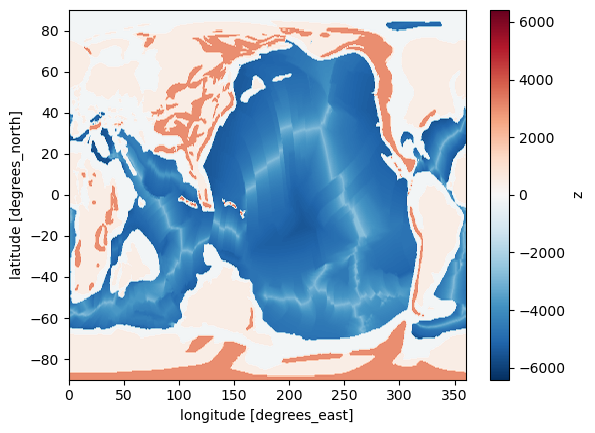

In [208]:
# Convert to 0-360
topoDS['lon'] = topoDS['lon'].where(topoDS['lon'] >= 0, topoDS['lon'] + 360)
topoDS = topoDS.sortby('lon')
topoDS.plot()

In [209]:
ensembleRegrid['topo'] = topoDS

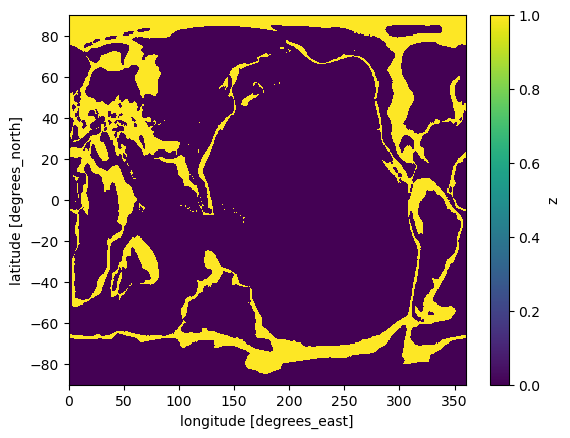

In [210]:
# Extract the variable
grid_data = ensembleRegrid['topo']

# Make every value an integer
grid_data = grid_data.astype(int)

# Create a mask for shallow shelf values
shelf = (grid_data >= -700) & (grid_data < 0)

# Set non-shelf values to 0
grid_data = grid_data.where(shelf, 0)
grid_data = grid_data.where(~shelf, 1)

ensembleRegrid['shelf'] = grid_data
ensembleRegrid['shelf'].plot()

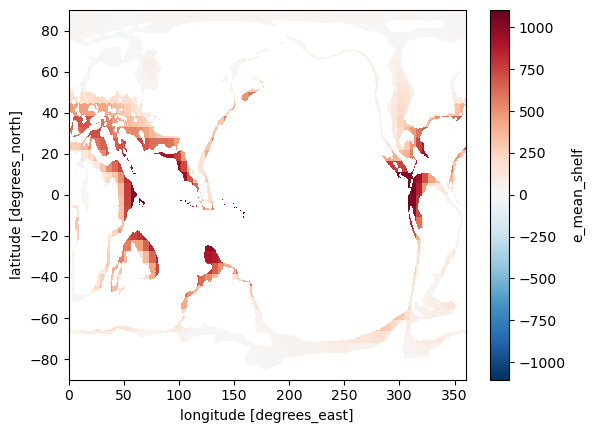

In [211]:
ensembleRegrid['e_mean_shelf'] = ensembleRegrid['e_mean'].where(ensembleRegrid.shelf == 1)
ensembleRegrid['e_mean_shelf'].plot()